# Galaxy10 DECals Classification — Alle Architektur-Varianten trainieren & vergleichen

## Übersicht
Dieses Notebook trainiert, validiert und testet **alle Architektur-Varianten** systematisch:
- **Basis**: `MINIMAL_MODEL`
- **Varianten**: V1–V12 (progressive Verbesserungen)
- **Vergleich**: Test-Genauigkeit, Parameterzahl, Trainingsverhalten

## Methodik
1. **Fixen Test-Split**: Einmalig abgetrennt vor allen Experimenten
2. **K-Fold Cross-Validation**: 5 Folds auf Trainungsdaten
3. **Pro Variante**: Separate Trainingsläufe mit identischen Hyperparametern
4. **Ranking**: Automatischer Vergleich aller Varianten

## Ergebnis
Detaillierte Metriken-Tabelle, Confusion Matrices für Top-Modelle und Ranking

In [17]:
import os
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.random import set_seed
from tensorflow.keras.models import clone_model

from data     import load_data, print_class_distribution, show_class_distribution, prepare_splits, LABEL_DICT, NUM_CLASSES
from models   import build_model
from train    import run_training
from evaluate import evaluate_models, plot_confusion_matrix, plot_training_history
from architecture_registry import ARCHITECTURE_VARIANTS, get_all_models

In [18]:
# --- Experiment-Schalter ---
USE_KFOLD   = False    # True = 5-fache Kreuzvalidierung | False = einfacher Train/Val-Split
LOAD_MODELS = False   # True = gespeicherte Checkpoints laden statt neu trainieren

# --- Datenpfade ---
DATA_PATH = './../data/Galaxy10_DECals.h5'
LOGS_DIR  = './../logs/'
REPORTS_DIR = './../reports/all_architectures/'

# --- Hyperparameter (KONSTANT über alle Varianten) ---
BATCH_SIZE     = 16
EPOCHS         = 100
LEARNING_RATE  = 1e-4
K_FOLDS        = 5        # nur relevant wenn USE_KFOLD = True
RANDOM_STATE   = 42

# --- Architektur-Varianten zur Testung ---
# Diese werden später aus der Registry geladen
VARIANTS_TO_TEST = None  # None = alle | oder spezifische Liste: ["MINIMAL_MODEL", "V1", "V7", "BEST_CNN"]

In [19]:
# Reproduzierbarkeit
set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# GPU-Speicher nur nach Bedarf allozieren
for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Memory Growth aktiviert: {gpu.name}")
    except RuntimeError as e:
        print(e)

print(f"TensorFlow {tf.__version__} | GPUs: {len(tf.config.list_physical_devices('GPU'))}")

# Verzeichnisse erstellen
os.makedirs(REPORTS_DIR, exist_ok=True)

Physical devices cannot be modified after being initialized
TensorFlow 2.21.0 | GPUs: 1


Dataset geladen: 17,736 Bilder, Shape (17736, 256, 256, 3)

Klasse   Beschreibung                              Anzahl
----------------------------------------------------------
0        Disturbed Galaxies                          1081
1        Merging Galaxies                            1853
2        Round Smooth Galaxies                       2645
3        In-between Round Smooth Galaxies            2027
4        Cigar Shaped Smooth Galaxies                 334
5        Barred Spiral Galaxies                      2043
6        Unbarred Tight Spiral Galaxies              1829
7        Unbarred Loose Spiral Galaxies              2628
8        Edge-on Galaxies without Bulge              1423
9        Edge-on Galaxies with Bulge                 1873
----------------------------------------------------------
GESAMT                                             17736


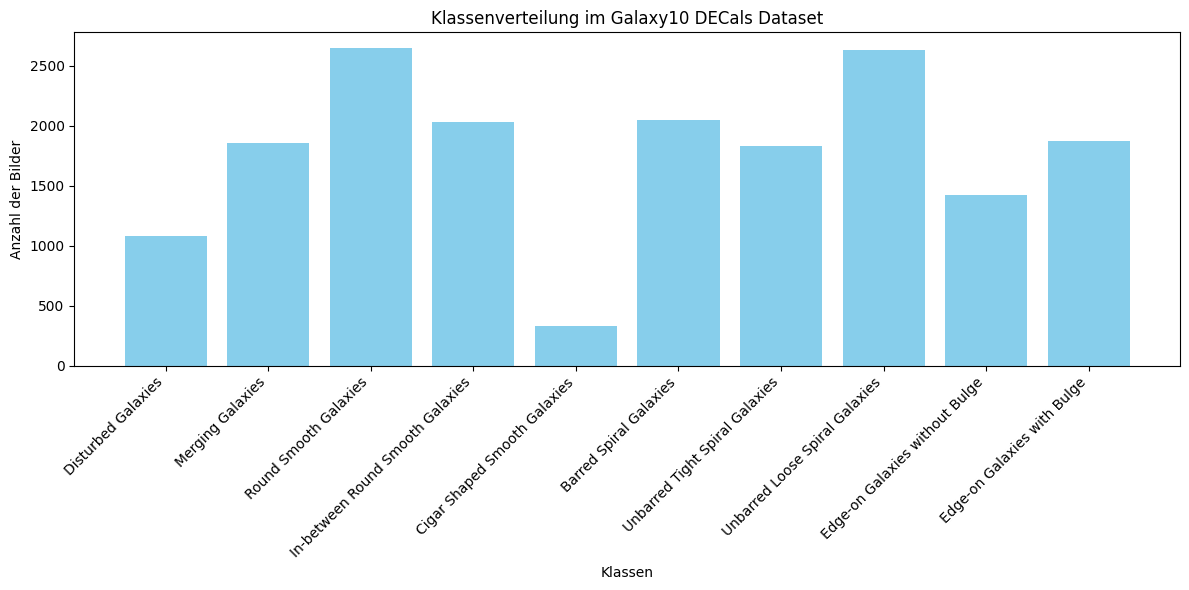

Gesamte Datengröße: 17736 Bilder


In [20]:
images_raw, labels = load_data(DATA_PATH)
counts = print_class_distribution(labels)
show_class_distribution(counts)

print(f"Gesamte Datengröße: {len(labels)} Bilder")

In [21]:
folds, X_test, y_test = prepare_splits(
    labels,
    use_kfold    = USE_KFOLD,
    k            = K_FOLDS,
    random_state = RANDOM_STATE,
)

print(f"Test-Set: {len(X_test)} Bilder")
print(f"Folds: {len(folds)} Folds")
print(f"Pro Fold ca. {len(folds[0][0])} Train-Samples, {len(folds[0][1])} Val-Samples")


Split-Modus : Einfacher Train/Val-Split
Train + Val : 14,188 Samples
Test        : 3,548 Samples
  Train 11,350 | Val 2,838
Test-Set: 3548 Bilder
Folds: 1 Folds
Pro Fold ca. 11350 Train-Samples, 2838 Val-Samples


In [22]:
# Alle Varianten aus Registry laden
all_variants = ARCHITECTURE_VARIANTS

# Falls VARIANTS_TO_TEST gesetzt ist, nur diese filtern
if VARIANTS_TO_TEST is not None:
    all_variants = [(n, m, d) for n, m, d in all_variants if n in VARIANTS_TO_TEST]

print(f"Zu testende Varianten: {len(all_variants)}")
for idx, (name, model_obj, description) in enumerate(all_variants, 1):
    model_obj.build(input_shape=(None, *images_raw.shape[1:]))
    params = model_obj.count_params()
    print(f"  [{idx:2d}] {name:15s} ({params:>10,} params) — {description[:50]}")

Zu testende Varianten: 14
  [ 1] MINIMAL_MODEL   (33,648,394 params) — Baseline: 3 Conv-Schichten, Flatten
  [ 2] V1              (33,649,290 params) — MINIMAL mit BatchNorm
  [ 3] V2              (   103,050 params) — V1 mit GlobalAveragePooling statt Flatten
  [ 4] V3              (   297,706 params) — Doppelte Conv-Layer pro Block (32-32, 64-64, 128-1
  [ 5] V4              (   619,178 params) — V3 + 256-Filter Block
  [ 6] V5              (   684,970 params) — V4 + tiefere Dense-Schichten (256→128)
  [ 7] V6              (   684,970 params) — V5 + Dropout(0.3) Regularisierung
  [ 8] V7              ( 2,492,202 params) — 5 Conv-Blöcke (mit 512-Block)
  [ 9] V8              ( 2,492,202 params) — V7 mit Dropout(0.3)


  [10] V9              ( 2,754,858 params) — V8 + Dense(512) für mehr Kapazität
  [11] BEST_CNN        ( 2,492,202 params) — Baseline: 5 Conv-Blöcke, Dense(256), Dropout(0.5)
  [12] V10             ( 1,244,458 params) — BEST_CNN ohne 512-Block (4 Conv-Blöcke)
  [13] V11             ( 2,754,858 params) — BEST_CNN mit Dense(512→256) + Dropout(0.3)
  [14] V12             ( 2,493,226 params) — BEST_CNN + BatchNorm in Dense-Schicht


In [23]:
# Dictionary zur Speicherung aller Ergebnisse
all_results = {}

for variant_idx, (variant_name, variant_model, variant_desc) in enumerate(all_variants, 1):
    print("\n" + "="*80)
    print(f"[{variant_idx}/{len(all_variants)}] Training: {variant_name}")
    print("="*80)
    
    # Model-Factory für diese Variante
    # build_model() cloned das Modell bereits intern, daher direkt das Template übergeben
    def make_model_factory(model_template):
        def factory():
            return build_model(model_template, learning_rate=LEARNING_RATE)
        return factory
    
    model_factory = make_model_factory(variant_model)
    
    # Logs-Verzeichnis für diese Variante
    variant_logs_dir = os.path.join(LOGS_DIR, variant_model.name)
    
    # Training durchführen
    fold_models, fold_histories = run_training(
        folds         = folds,
        images_raw    = images_raw,
        labels        = labels,
        logs_dir      = variant_logs_dir,
        model_factory = model_factory,
        batch_size    = BATCH_SIZE,
        epochs        = EPOCHS,
        load_models   = LOAD_MODELS,
    )
    
    # Ergebnisse speichern
    all_results[variant_name] = {
        'model_name': variant_model.name,
        'description': variant_desc,
        'fold_models': fold_models,
        'fold_histories': fold_histories,
        'logs_dir': variant_logs_dir,
    }
    
    print(f"✓ {variant_name} Training abgeschlossen")

print("\n" + "="*80)
print("ALLE TRAININGS ABGESCHLOSSEN")
print("="*80)


[1/14] Training: MINIMAL_MODEL

Fold 1 / 1: Starte Training


/home/alexa/Projects/deep-learning/tf-gpu-env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1779026492.733849     941 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1779026496.010069    1124 cuda_dnn.cc:461] Loaded cuDNN version 92101


710/710 ━━━━━━━━━━━━━━━━━━━━ 44s 55ms/step - accuracy: 0.2485 - loss: 2.0401 - val_accuracy: 0.2442 - val_loss: 1.9518 - learning_rate: 1.0000e-04
Epoch 2/100
710/710 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.2951 - loss: 1.9085 - val_accuracy: 0.2452 - val_loss: 1.9674 - learning_rate: 1.0000e-04
Epoch 3/100
710/710 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.3423 - loss: 1.8165 - val_accuracy: 0.2918 - val_loss: 1.8993 - learning_rate: 1.0000e-04
Epoch 4/100
710/710 ━━━━━━━━━━━━━━━━━━━━ 38s 53ms/step - accuracy: 0.3896 - loss: 1.7138 - val_accuracy: 0.3915 - val_loss: 1.6541 - learning_rate: 1.0000e-04
Epoch 5/100
710/710 ━━━━━━━━━━━━━━━━━━━━ 38s 53ms/step - accuracy: 0.4113 - loss: 1.6298 - val_accuracy: 0.4264 - val_loss: 1.5860 - learning_rate: 1.0000e-04
Epoch 6/100
710/710 ━━━━━━━━━━━━━━━━━━━━ 38s 53ms/step - accuracy: 0.4278 - loss: 1.5804 - val_accuracy: 0.4320 - val_loss: 1.5385 - learning_rate: 1.0000e-04
Epoch 7/100
710/710 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - a


MINIMAL_MODEL:


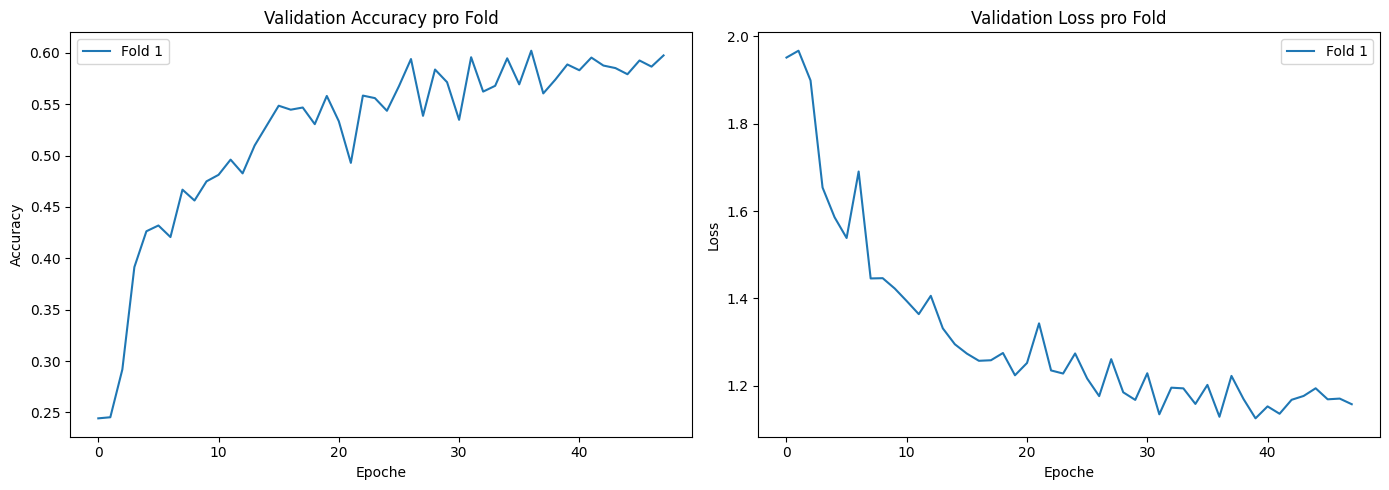


V1:


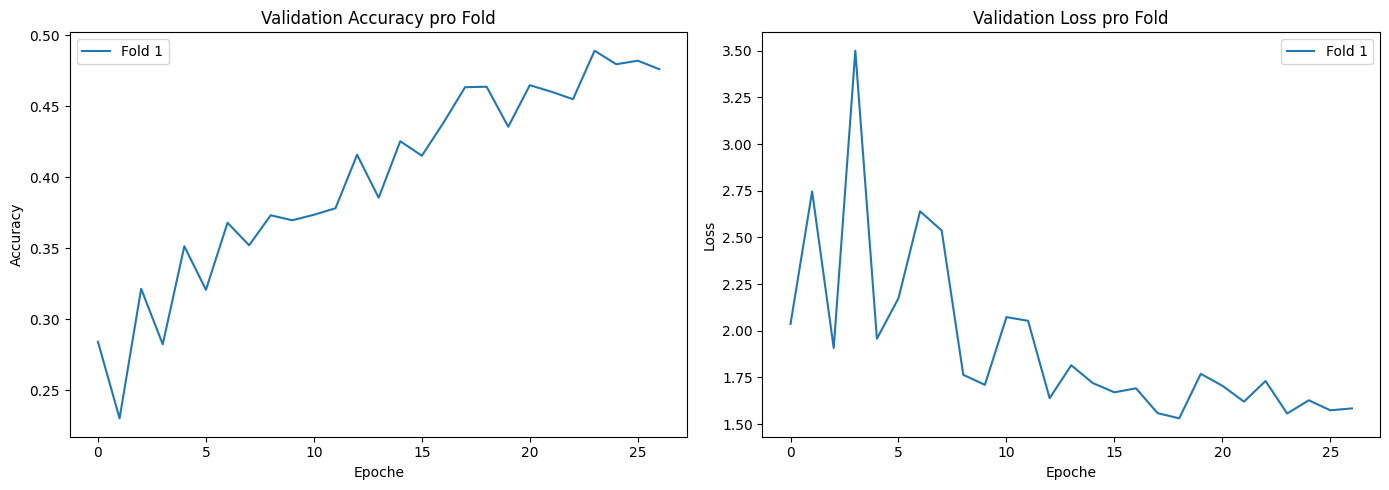


V2:


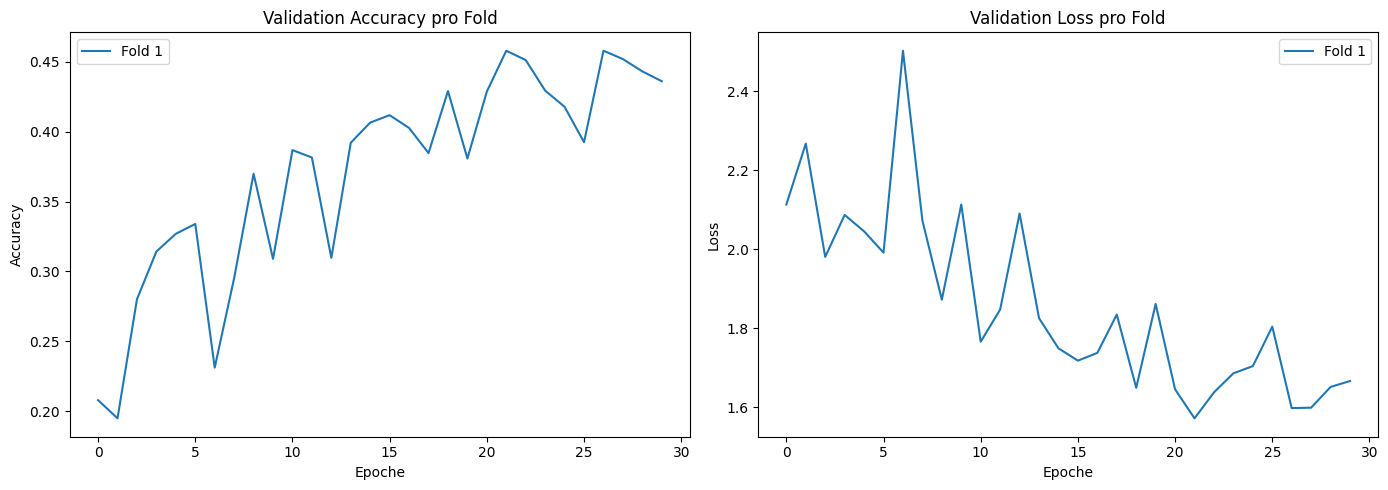


V3:


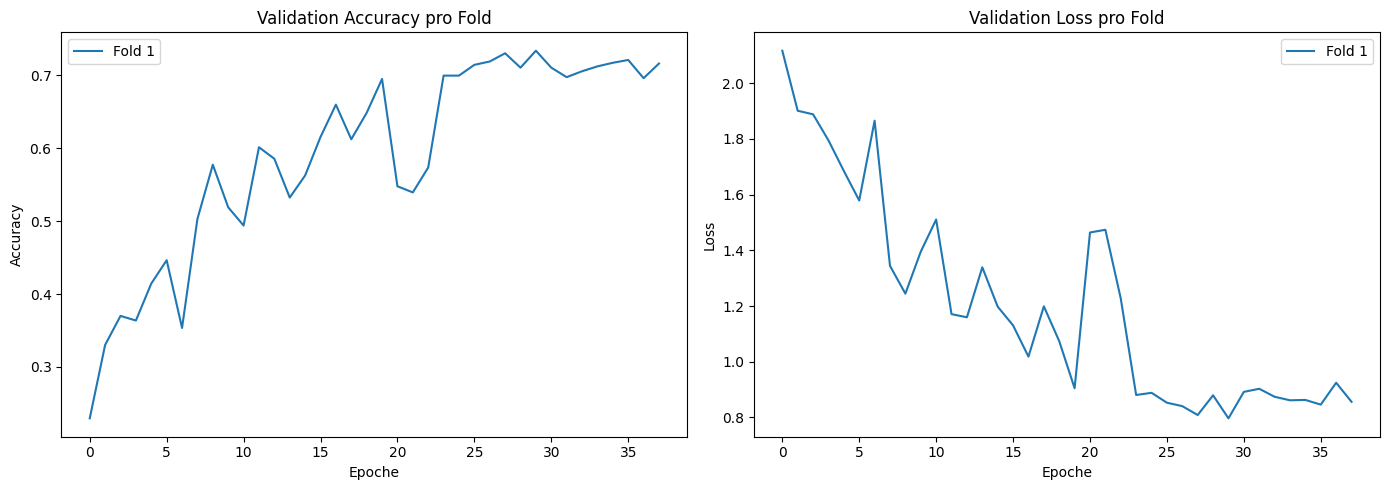


V4:


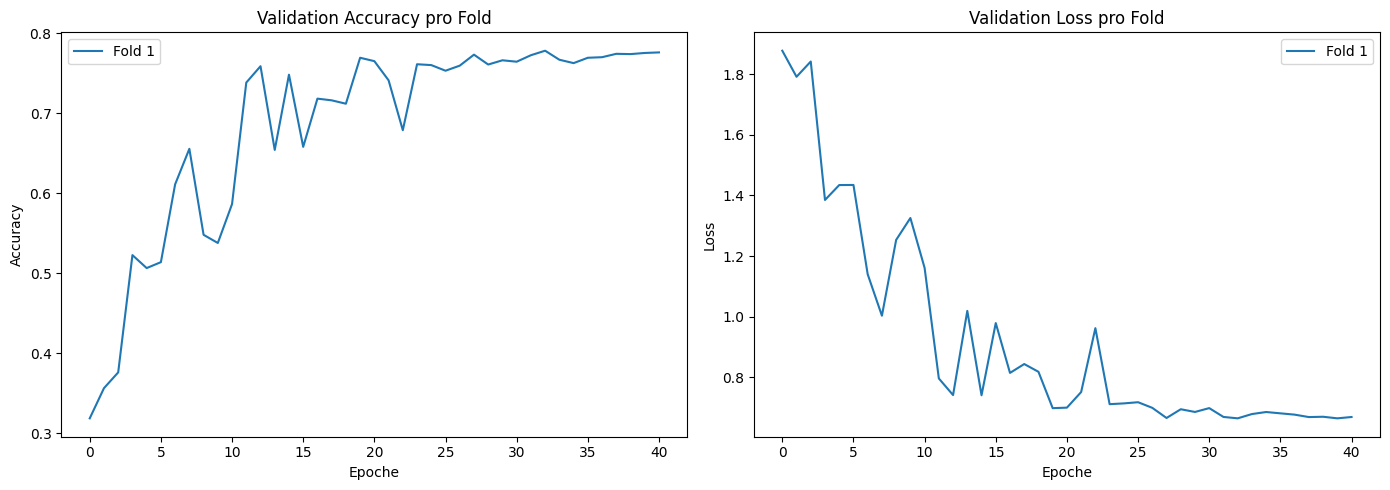


V5:


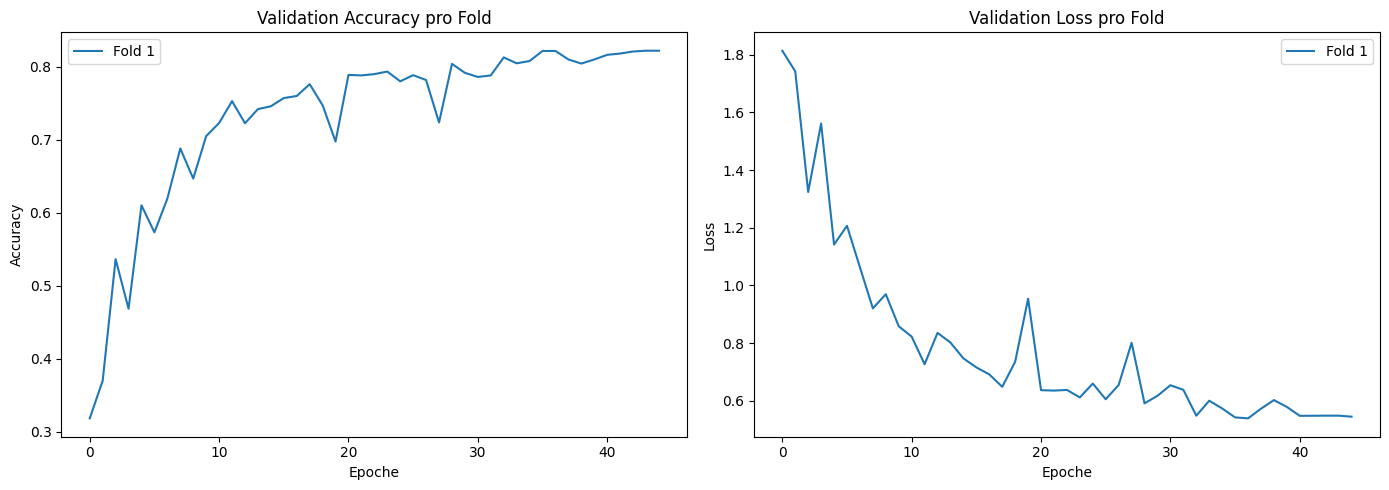


V6:


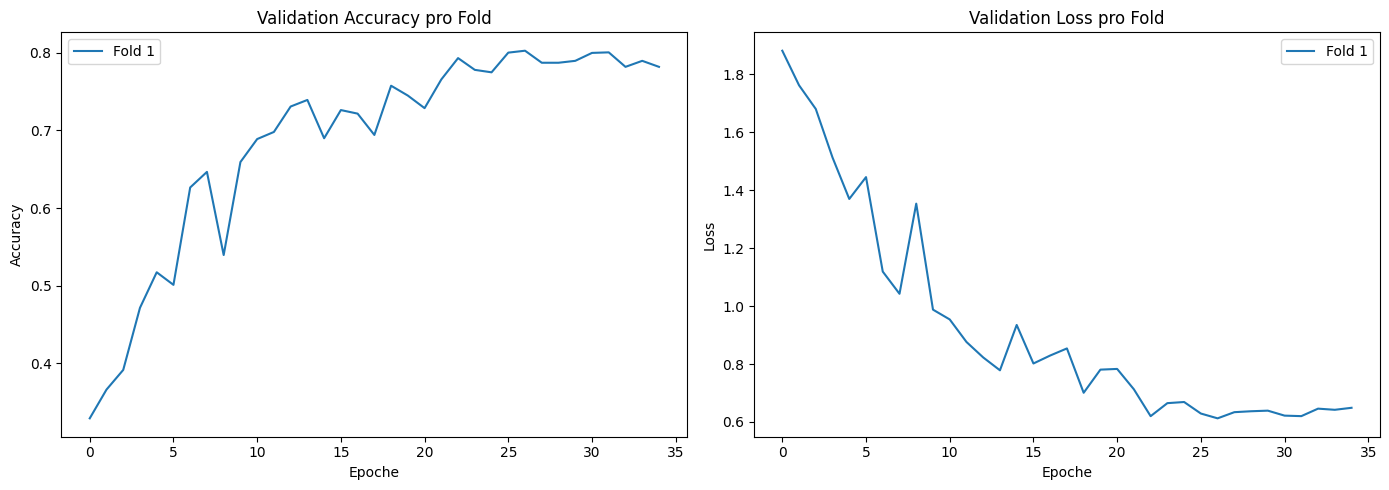


V7:


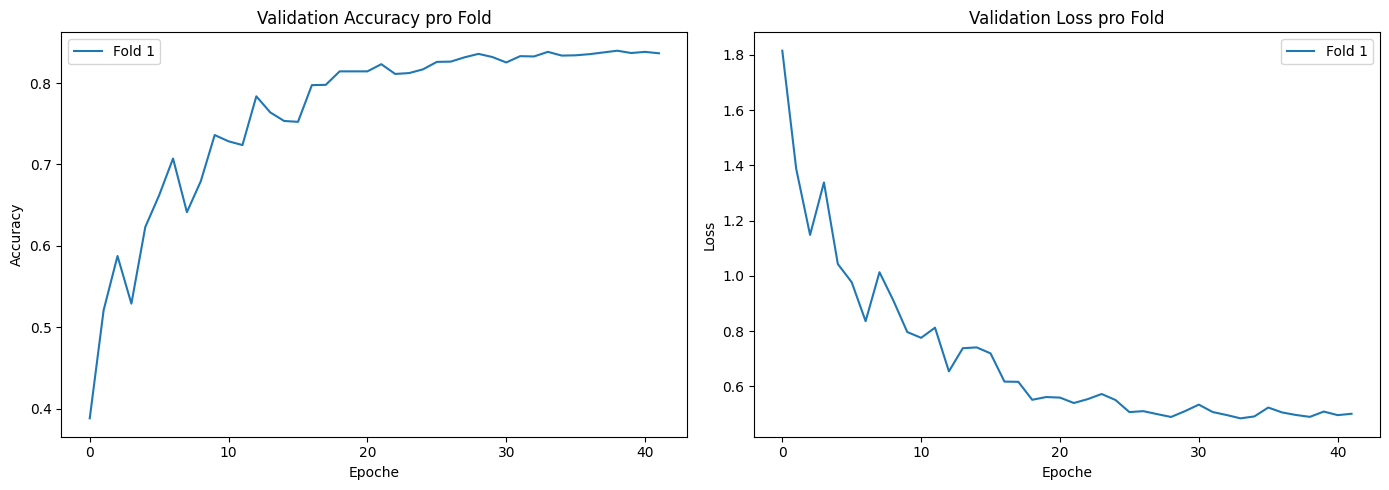


V8:


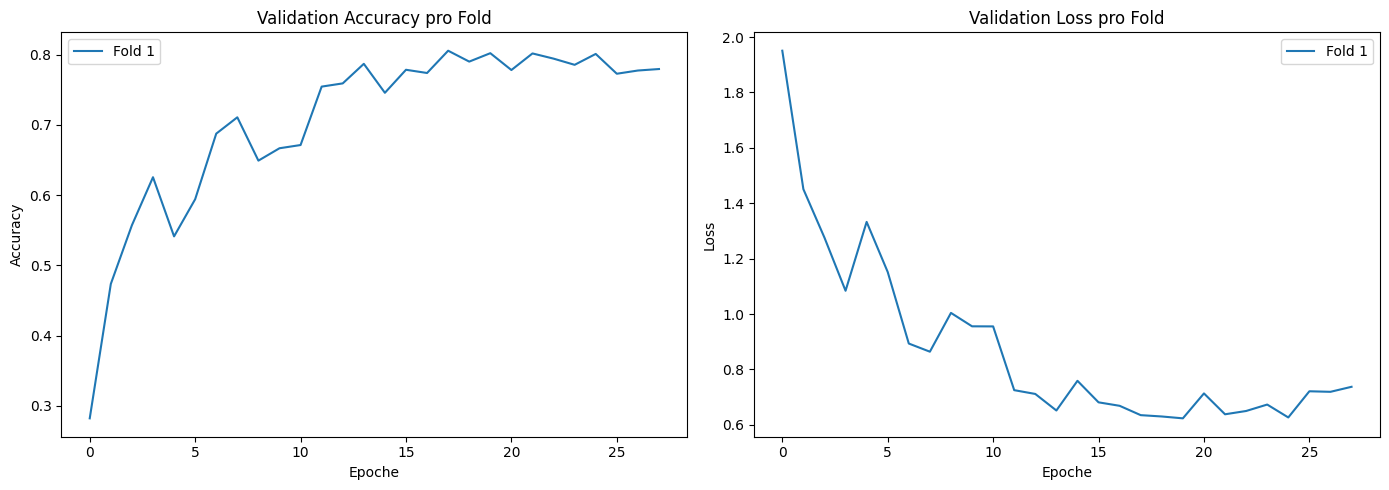


V9:


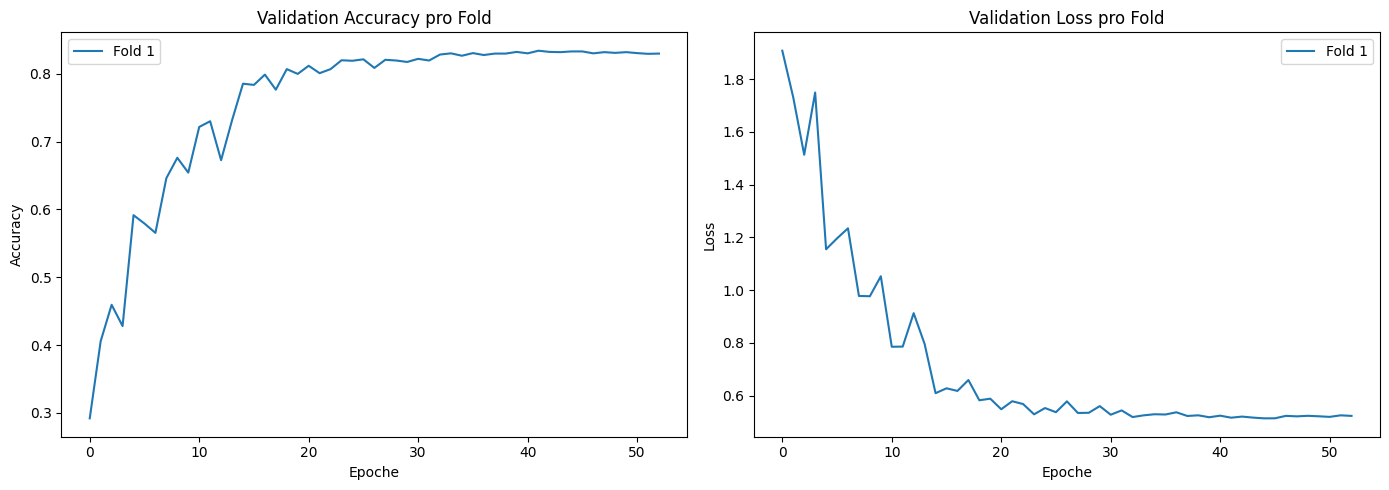


BEST_CNN:


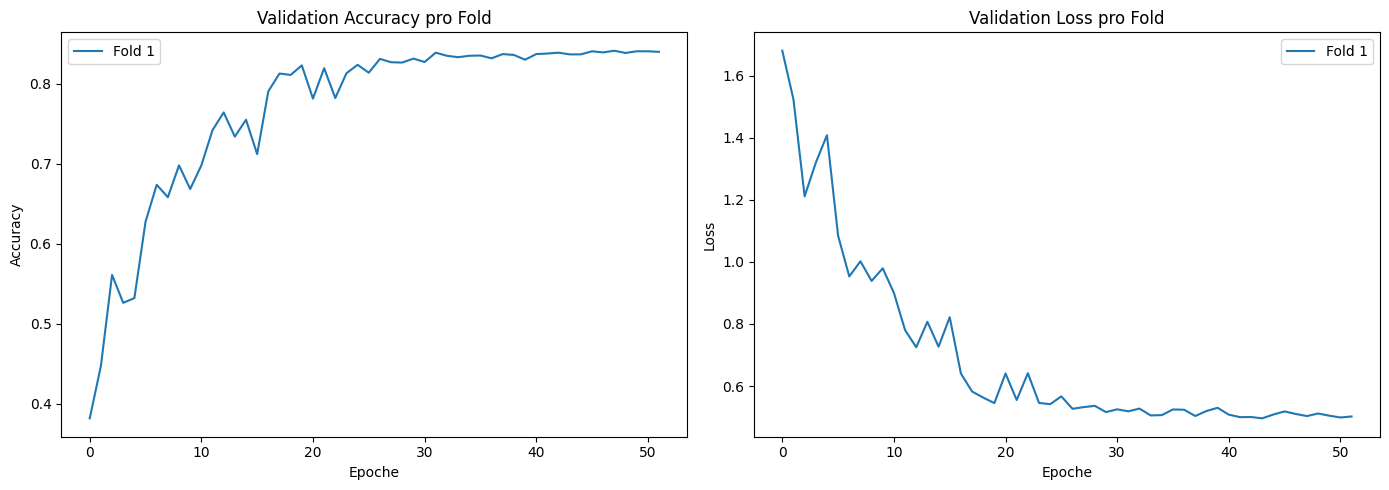


V10:


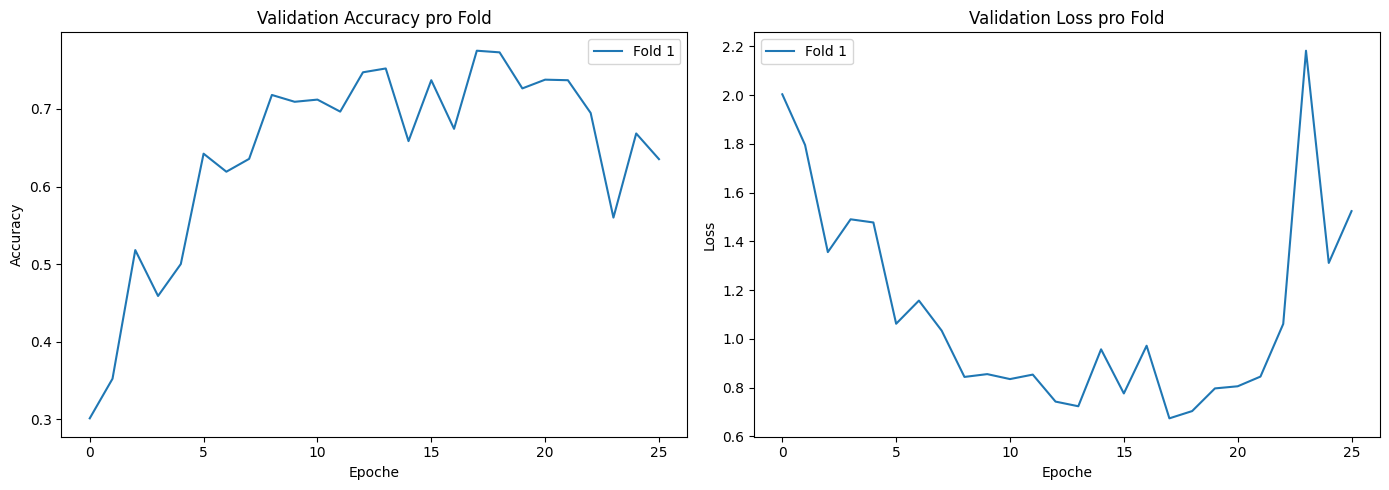


V11:


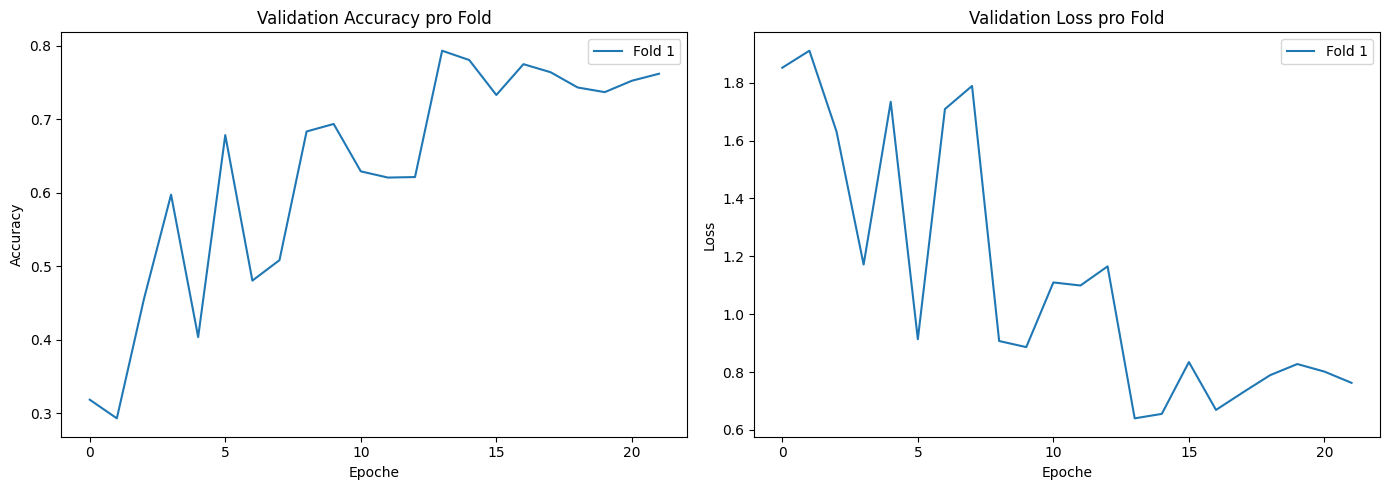


V12:


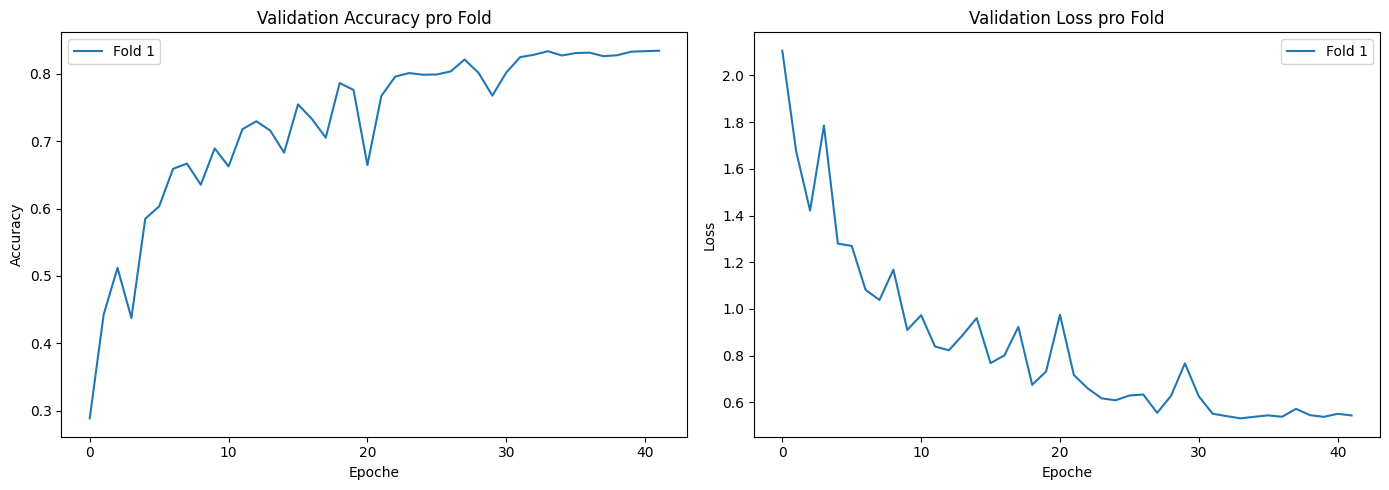

In [24]:
# Trainings-Kurven pro Variante visualisieren
for variant_name, results in all_results.items():
    fold_histories = results['fold_histories']
    if fold_histories is not None and len(fold_histories) > 0:
        print(f"\n{variant_name}:")
        plot_training_history(fold_histories)

In [25]:
# Test-Evaluation für alle Varianten
test_results_list = []

for variant_name, results in all_results.items():
    fold_models = results['fold_models']
    
    test_accuracies, best_model, best_fold_idx = evaluate_models(
        fold_models = fold_models,
        images_raw  = images_raw,
        labels      = labels,
        X_test      = X_test,
        batch_size  = BATCH_SIZE,
    )
    
    # Speichere Ergebnisse
    test_acc_mean = np.mean(test_accuracies)
    test_acc_std = np.std(test_accuracies)
    
    results['test_accuracies'] = test_accuracies
    results['best_model'] = best_model
    results['best_fold_idx'] = best_fold_idx
    results['test_acc_mean'] = test_acc_mean
    results['test_acc_std'] = test_acc_std
    
    test_results_list.append({
        'Variante': variant_name,
        'Test Acc (Mittel)': test_acc_mean,
        'Test Acc (Std)': test_acc_std,
        'Best Fold': best_fold_idx + 1,
    })
    
    print(f"{variant_name:20s} | Test Acc: {test_acc_mean:.4f} ± {test_acc_std:.4f} | Best Fold: {best_fold_idx + 1}")

print("\nTest-Evaluation abgeschlossen")

Starte Evaluierung auf dem Test-Set...

  Fold 1 / 1:
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.5840 - loss: 1.1525
  --> Test Accuracy: 0.5840 (58.40 %)

Durchschnittliche Test Accuracy : 0.5840
Standardabweichung              : 0.0000
Bestes Modell                   : Fold 1
  Test Accuracy                 : 0.5840 (58.40 %)
MINIMAL_MODEL        | Test Acc: 0.5840 ± 0.0000 | Best Fold: 1
Starte Evaluierung auf dem Test-Set...

  Fold 1 / 1:
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.4589 - loss: 1.5707
  --> Test Accuracy: 0.4589 (45.89 %)

Durchschnittliche Test Accuracy : 0.4589
Standardabweichung              : 0.0000
Bestes Modell                   : Fold 1
  Test Accuracy                 : 0.4589 (45.89 %)
V1                   | Test Acc: 0.4589 ± 0.0000 | Best Fold: 1
Starte Evaluierung auf dem Test-Set...

  Fold 1 / 1:
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.4524 - loss: 1.5806
  --> Test Accuracy: 0.4524 (45.24 %)

Durchschnittliche

In [27]:
# Erstelle Vergleichstabelle
comparison_data = []

for variant_name, (variant_name_registry, variant_model, variant_desc) in zip(
    [r['Variante'] for r in test_results_list],
    all_variants
):
    variant_info = all_results[variant_name]
    
    # Parameterzahl
    variant_model.build(input_shape=(None, *images_raw.shape[1:]))
    num_params = variant_model.count_params()
    
    comparison_data.append({
        'Rang': None,  # wird später gesetzt
        'Variante': variant_name,
        'Modell': variant_model.name,
        'Parameter': num_params,
        'Test Acc (Mittel)': variant_info['test_acc_mean'],
        'Test Acc (Std)': variant_info['test_acc_std'],
        'Fold mit Best Val': variant_info['best_fold_idx'] + 1,
    })

# DataFrame erstellen und nach Test-Acc sortieren
df_comparison = pd.DataFrame(comparison_data).sort_values('Test Acc (Mittel)', ascending=False).reset_index(drop=True)
df_comparison['Rang'] = range(1, len(df_comparison) + 1)

print("\n" + "="*100)
print("RANKING: ARCHITEKTUR-VARIANTEN")
print("="*100)
print(df_comparison.to_string(index=False))
print("="*100)

# Speichere Rankings als CSV und JSON
df_comparison.to_csv(os.path.join(REPORTS_DIR, 'architecture_ranking.csv'), index=False)
print(f"\n✓ Rankings gespeichert: {os.path.join(REPORTS_DIR, 'architecture_ranking.csv')}")


RANKING: ARCHITEKTUR-VARIANTEN
 Rang      Variante                    Modell  Parameter  Test Acc (Mittel)  Test Acc (Std)  Fold mit Best Val
    1            V7       v7_five_conv_blocks    2492202           0.823563             0.0                  1
    2      BEST_CNN          9_conv_layer_cnn    2492202           0.823281             0.0                  1
    3            V9         v9_with_512_dense    2754858           0.822717             0.0                  1
    4           V12         v12_with_dense_bn    2493226           0.821871             0.0                  1
    5            V5           v5_deeper_dense     684970           0.806652             0.0                  1
    6            V6        v6_with_dropout_03     684970           0.786922             0.0                  1
    7            V8      v8_five_conv_dropout    2492202           0.779312             0.0                  1
    8           V11 v11_best_cnn_deeper_dense    2754858           0.769448     

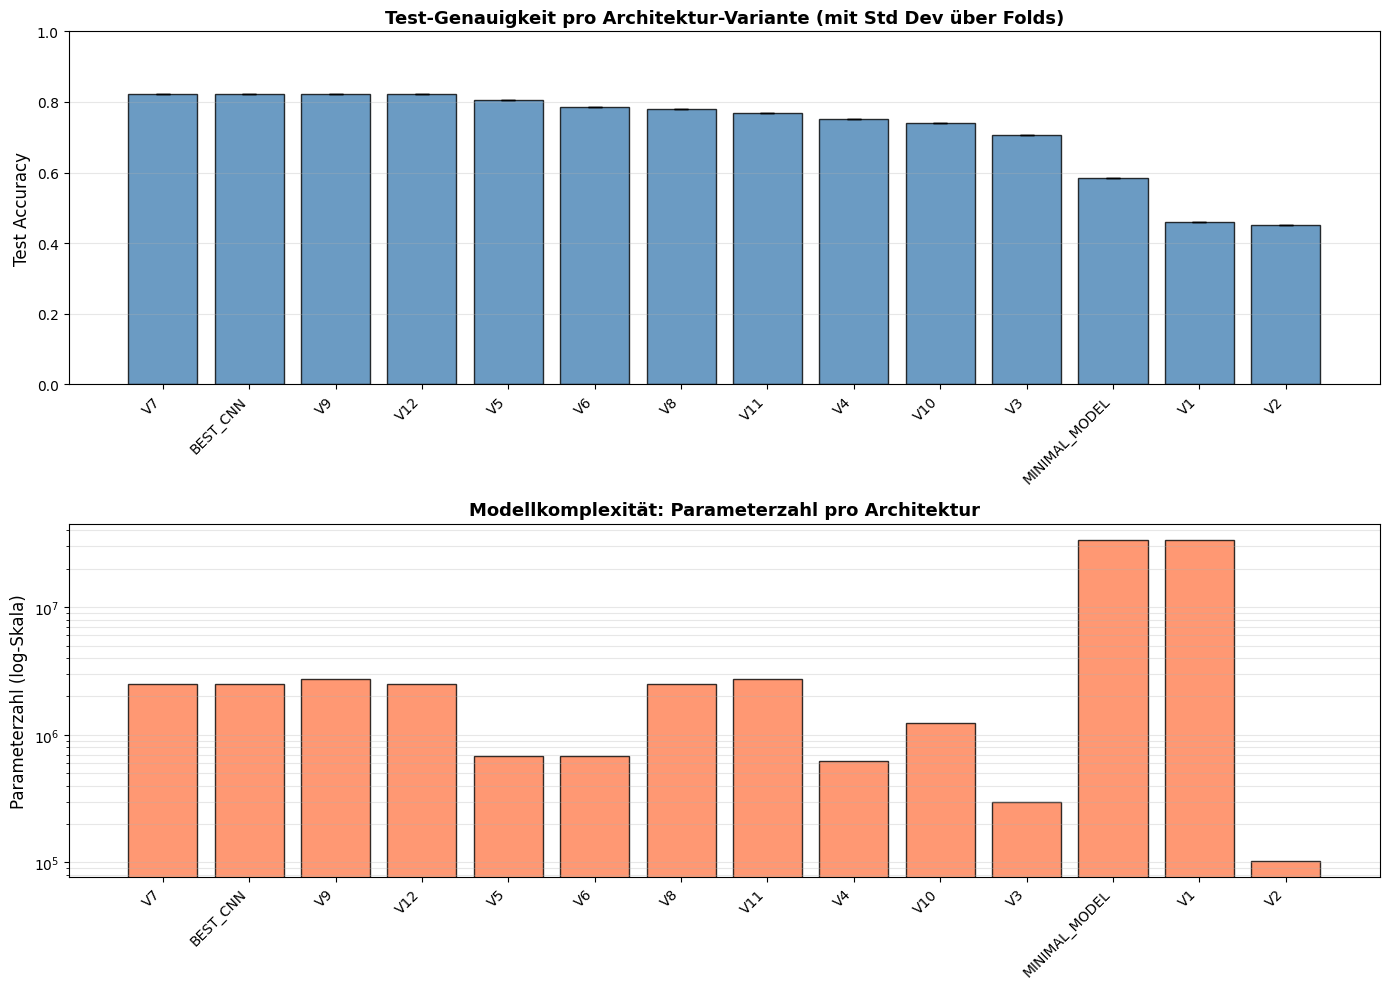

✓ Visualisierung gespeichert: ./../reports/all_architectures/comparison_accuracy_vs_complexity.png


In [28]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Test-Accuracy (mit Error Bars)
ax = axes[0]
x_pos = range(len(df_comparison))
ax.bar(
    x_pos,
    df_comparison['Test Acc (Mittel)'],
    yerr=df_comparison['Test Acc (Std)'],
    capsize=5,
    color='steelblue',
    alpha=0.8,
    edgecolor='black'
)
ax.set_xticks(x_pos)
ax.set_xticklabels(df_comparison['Variante'], rotation=45, ha='right')
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Test-Genauigkeit pro Architektur-Variante (mit Std Dev über Folds)', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

# Plot 2: Parameterzahl (Log-Skala)
ax = axes[1]
ax.bar(
    x_pos,
    df_comparison['Parameter'],
    color='coral',
    alpha=0.8,
    edgecolor='black'
)
ax.set_xticks(x_pos)
ax.set_xticklabels(df_comparison['Variante'], rotation=45, ha='right')
ax.set_ylabel('Parameterzahl (log-Skala)', fontsize=12)
ax.set_yscale('log')
ax.set_title('Modellkomplexität: Parameterzahl pro Architektur', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3, which='both')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'comparison_accuracy_vs_complexity.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Visualisierung gespeichert: {os.path.join(REPORTS_DIR, 'comparison_accuracy_vs_complexity.png')}")


[Rang 1] V7


/home/alexa/Projects/deep-learning/tf-gpu-env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step
Confusion Matrix gespeichert: ./../reports/all_architectures/confusion_matrix_rank1_V7.png


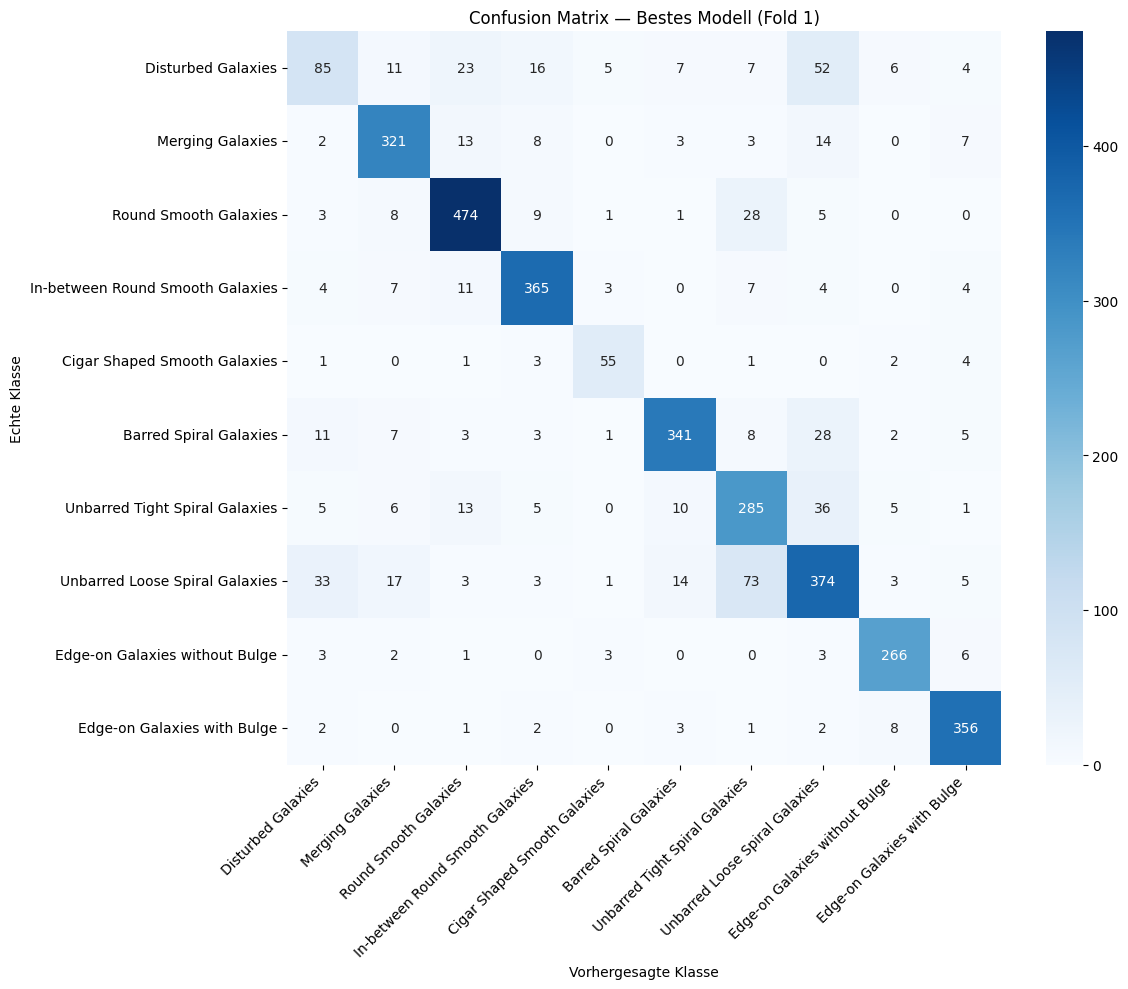

✓ Konfusionsmatrix gespeichert: ./../reports/all_architectures/confusion_matrix_rank1_V7.png

[Rang 2] BEST_CNN


/home/alexa/Projects/deep-learning/tf-gpu-env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step
Confusion Matrix gespeichert: ./../reports/all_architectures/confusion_matrix_rank2_BEST_CNN.png


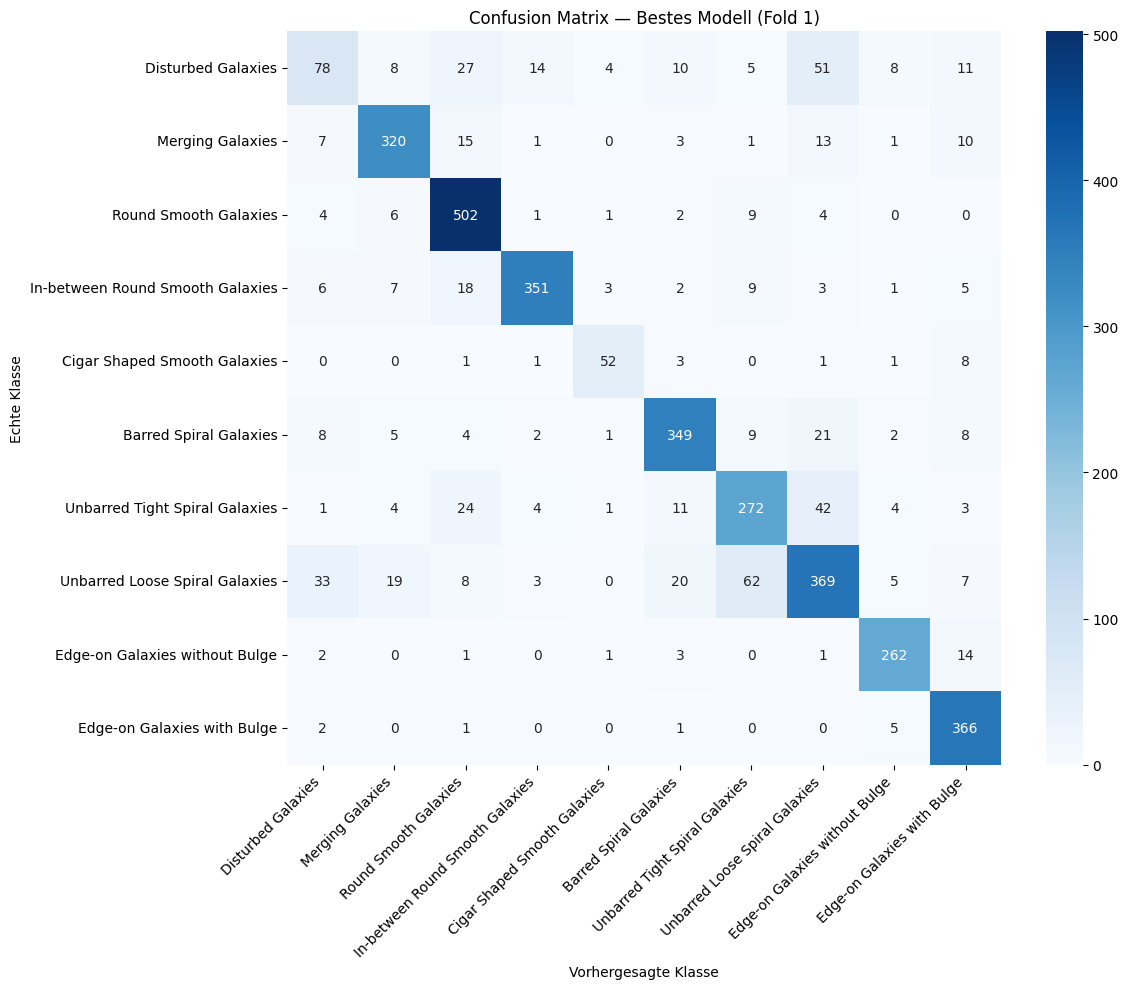

✓ Konfusionsmatrix gespeichert: ./../reports/all_architectures/confusion_matrix_rank2_BEST_CNN.png

[Rang 3] V9


/home/alexa/Projects/deep-learning/tf-gpu-env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step
Confusion Matrix gespeichert: ./../reports/all_architectures/confusion_matrix_rank3_V9.png


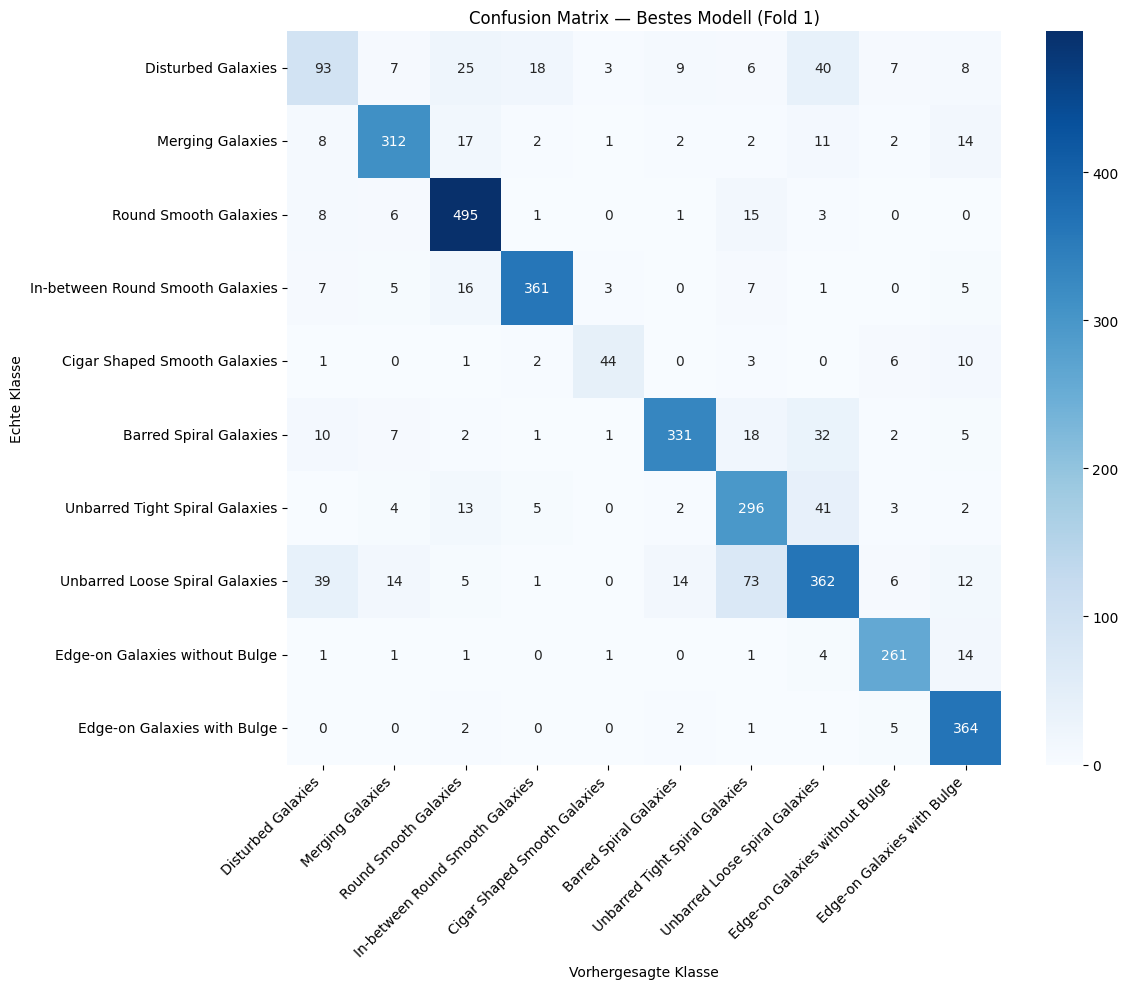

✓ Konfusionsmatrix gespeichert: ./../reports/all_architectures/confusion_matrix_rank3_V9.png


In [29]:
# Konfusionsmatrizen für Top-3 Modelle
top_3_variants = df_comparison.head(3)['Variante'].tolist()

for rank, variant_name in enumerate(top_3_variants, 1):
    results = all_results[variant_name]
    best_model = results['best_model']
    best_fold_idx = results['best_fold_idx']
    
    print(f"\n{'='*60}")
    print(f"[Rang {rank}] {variant_name}")
    print(f"{'='*60}")
    
    save_path = os.path.join(REPORTS_DIR, f'confusion_matrix_rank{rank}_{variant_name}.png')
    
    plot_confusion_matrix(
        best_model    = best_model,
        images_raw    = images_raw,
        labels        = labels,
        X_test        = X_test,
        best_fold_idx = best_fold_idx,
        batch_size    = BATCH_SIZE,
        save_path     = save_path,
    )
    
    print(f"✓ Konfusionsmatrix gespeichert: {save_path}")

In [30]:
# Exportiere detaillierte Metriken
detailed_metrics = {}

for variant_name, results in all_results.items():
    test_accuracies = results['test_accuracies']
    test_acc_mean = results['test_acc_mean']
    test_acc_std = results['test_acc_std']
    
    detailed_metrics[variant_name] = {
        'model_name': results['model_name'],
        'description': results['description'],
        'test_accuracies_per_fold': [float(acc) for acc in test_accuracies],
        'test_accuracy_mean': float(test_acc_mean),
        'test_accuracy_std': float(test_acc_std),
        'best_fold_idx': int(results['best_fold_idx']),
        'logs_directory': results['logs_dir'],
    }

# Speichere als JSON
metrics_json_path = os.path.join(REPORTS_DIR, 'detailed_metrics.json')
with open(metrics_json_path, 'w') as f:
    json.dump(detailed_metrics, f, indent=2)
print(f"✓ Detaillierte Metriken gespeichert: {metrics_json_path}")

# Exportiere auch als erweiterte CSV
extended_csv_data = []
for variant_name, results in all_results.items():
    test_accs = results['test_accuracies']
    for fold_idx, fold_acc in enumerate(test_accs):
        extended_csv_data.append({
            'Variante': variant_name,
            'Fold': fold_idx + 1,
            'Test_Accuracy': fold_acc,
        })

df_extended = pd.DataFrame(extended_csv_data)
extended_csv_path = os.path.join(REPORTS_DIR, 'test_accuracies_per_fold.csv')
df_extended.to_csv(extended_csv_path, index=False)
print(f"✓ Fold-weise Metriken gespeichert: {extended_csv_path}")

✓ Detaillierte Metriken gespeichert: ./../reports/all_architectures/detailed_metrics.json
✓ Fold-weise Metriken gespeichert: ./../reports/all_architectures/test_accuracies_per_fold.csv


In [31]:
print("\n" + "="*80)
print("ZUSAMMENFASSUNG: ARCHITEKTUR-VERGLEICH")
print("="*80)

best_variant = df_comparison.iloc[0]
second_variant = df_comparison.iloc[1] if len(df_comparison) > 1 else None
worst_variant = df_comparison.iloc[-1]

print(f"\n✓ BESTE VARIANTE:")
print(f"  Name:       {best_variant['Variante']}")
print(f"  Test Acc:   {best_variant['Test Acc (Mittel)']:.4f} ± {best_variant['Test Acc (Std)']:.4f}")
print(f"  Parameter:  {best_variant['Parameter']:,}")
print(f"  Modell:     {best_variant['Modell']}")

if second_variant is not None:
    print(f"\n✓ ZWEITE BESTE:")
    print(f"  Name:       {second_variant['Variante']}")
    print(f"  Test Acc:   {second_variant['Test Acc (Mittel)']:.4f} ± {second_variant['Test Acc (Std)']:.4f}")
    print(f"  Diff zu Best: {(best_variant['Test Acc (Mittel)'] - second_variant['Test Acc (Mittel)'])*100:.2f}%")

print(f"\n• SCHLECHTESTE VARIANTE:")
print(f"  Name:       {worst_variant['Variante']}")
print(f"  Test Acc:   {worst_variant['Test Acc (Mittel)']:.4f} ± {worst_variant['Test Acc (Std)']:.4f}")

print(f"\n• AUSGABEDATEIEN:")
print(f"  - {REPORTS_DIR}architecture_ranking.csv")
print(f"  - {REPORTS_DIR}detailed_metrics.json")
print(f"  - {REPORTS_DIR}test_accuracies_per_fold.csv")
print(f"  - {REPORTS_DIR}comparison_accuracy_vs_complexity.png")
print(f"  - {REPORTS_DIR}confusion_matrix_rank*.png")

print("\n" + "="*80)
print(f"Experiment abgeschlossen: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)


ZUSAMMENFASSUNG: ARCHITEKTUR-VERGLEICH

✓ BESTE VARIANTE:
  Name:       V7
  Test Acc:   0.8236 ± 0.0000
  Parameter:  2,492,202
  Modell:     v7_five_conv_blocks

✓ ZWEITE BESTE:
  Name:       BEST_CNN
  Test Acc:   0.8233 ± 0.0000
  Diff zu Best: 0.03%

• SCHLECHTESTE VARIANTE:
  Name:       V2
  Test Acc:   0.4524 ± 0.0000

• AUSGABEDATEIEN:
  - ./../reports/all_architectures/architecture_ranking.csv
  - ./../reports/all_architectures/detailed_metrics.json
  - ./../reports/all_architectures/test_accuracies_per_fold.csv
  - ./../reports/all_architectures/comparison_accuracy_vs_complexity.png
  - ./../reports/all_architectures/confusion_matrix_rank*.png

Experiment abgeschlossen: 2026-05-18 07:55:39
